<a href="https://colab.research.google.com/github/selvatrimarta80-cpu/Analisis_Numerik_Donat_Selva/blob/main/25083010008_Selva_Tri_Martadinata_Kapal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nama : Selva Tri Martadinata**

**NPM : 25083010008**

**Kelas : Analisis Numerik/ A**

##**Perhitungan Volume Kedua Lambung Kapal**

Diketahui:
- 1 dash dan 1 ruang kosong pada grid = 5 + 5 cm = 10 cm atau 0,1 m.
- Lantai kapal dianggap datar
- Tampak depan dianggap berbentuk persegi panjang
- Volume reserve buoyancy tidak dihitung
- Hitung volume kedua lambung kapal


## **1. Import Library dan Menampilkan gambar**

In [117]:
from google.colab import files

uploaded = files.upload()

Saving Kapal.png to Kapal (2).png


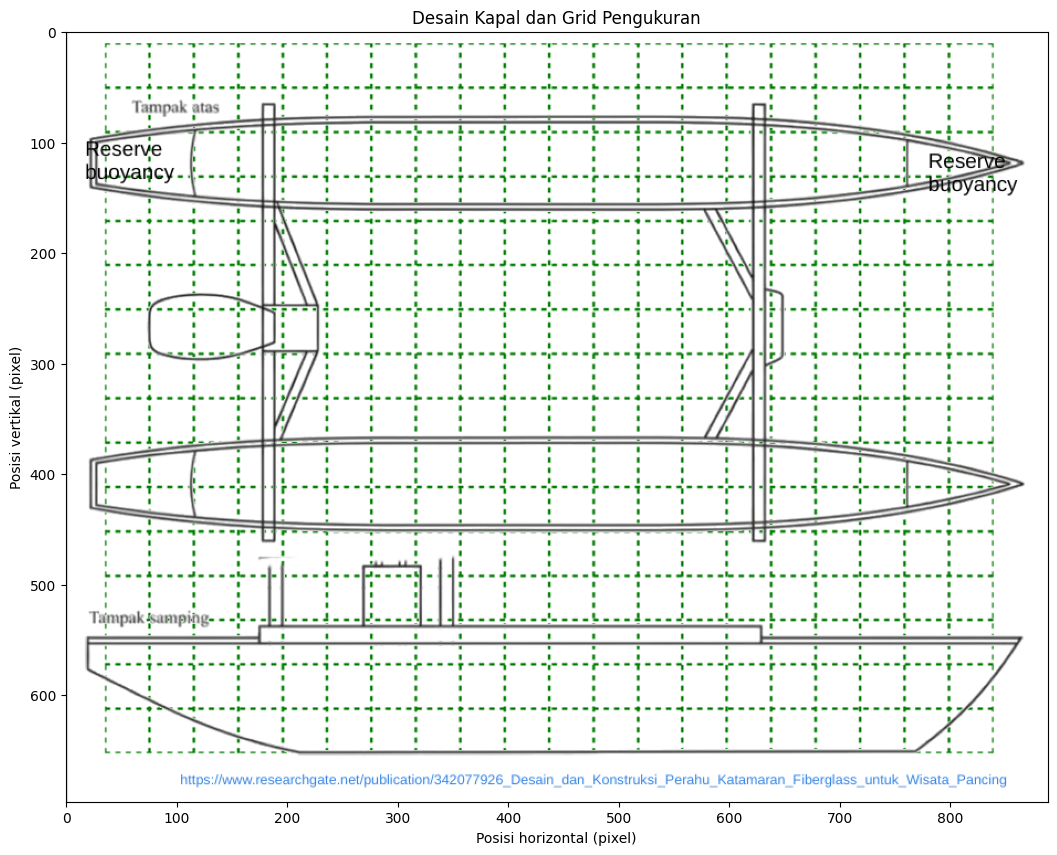

In [133]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd

# Membaca gambar
nama_file = "Kapal (1).png"
gambar = mpimg.imread(nama_file)

# Menampilkan gambar
plt.figure(figsize=(16, 10))
plt.imshow(gambar)
plt.title("Desain Kapal dan Grid Pengukuran")
plt.xlabel("Posisi horizontal (pixel)")
plt.ylabel("Posisi vertikal (pixel)")
plt.grid(False)

plt.show()

## **2. Menentukan Daerah Perhitungan dan Titik Penampang**

Bagian kapal yang diberi keterangan **reserve buoyancy** pada kedua ujung tidak dimasukkan ke dalam perhitungan volume. Oleh karena itu, perhitungan hanya dilakukan pada bagian utama lambung yang berada di antara kedua daerah reserve buoyancy tersebut.

Berdasarkan grid pada gambar, jarak antara dua garis grid adalah **10 cm** atau **0,1 m**. Daerah utama lambung memiliki **16 interval grid**, sehingga terdapat **17 titik pengukuran**.

Posisi titik pengukuran dinyatakan sebagai:

$$
x_0, x_1, x_2, \ldots, x_{16}
$$

dengan jarak antar titik sebesar **0,1 m**.

Dengan demikian, posisi titik pengukuran dimulai dari:

$$
x_0 = 0
$$

dan berlanjut setiap 0,1 m hingga:

$$
x_{16} = 1,6 \text{ m}
$$

Titik-titik tersebut selanjutnya digunakan sebagai acuan untuk menentukan ukuran penampang lambung pada setiap posisi.


**a). Penentuan Titik Pengukuran Lambung Kapal**

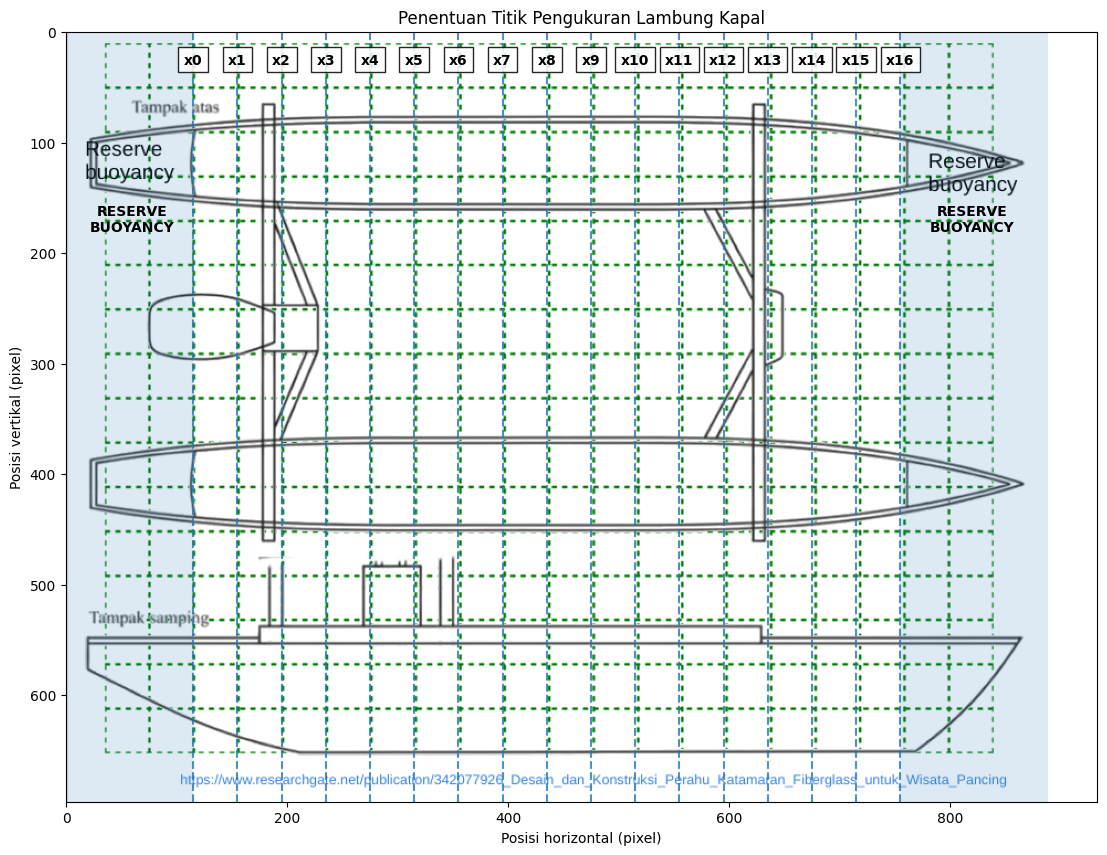

In [134]:
# Posisi titik pengukuran pada gambar
# Jarak antar titik = 40 pixel
x_titik = [115 + i * 40 for i in range(17)]

plt.figure(figsize=(16, 10))
plt.imshow(gambar)

# Membuat garis vertikal pada setiap titik pengukuran
for i, x in enumerate(x_titik):
    plt.axvline(
        x=x,
        linestyle="--",
        linewidth=1.5,
        alpha=0.8
    )

    # Nomor titik
    plt.text(
        x,
        25,
        f"x{i}",
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            alpha=0.85,
            edgecolor="black"
        )
    )

# Menandai daerah reserve buoyancy
plt.axvspan(0, 115, alpha=0.15)
plt.axvspan(755, 889, alpha=0.15)

plt.text(
    60, 180,
    "RESERVE\nBUOYANCY",
    ha="center",
    fontsize=10,
    fontweight="bold"
)

plt.text(
    820, 180,
    "RESERVE\nBUOYANCY",
    ha="center",
    fontsize=10,
    fontweight="bold"
)

plt.title("Penentuan Titik Pengukuran Lambung Kapal")
plt.xlabel("Posisi horizontal (pixel)")
plt.ylabel("Posisi vertikal (pixel)")

plt.show()

**b). Membuat tabel posisi titik**

In [121]:
x_m = np.arange(0, 1.7, 0.1)

tabel_x = {
    "Titik": [f"x{i}" for i in range(17)],
    "Posisi (m)": x_m
}

import pandas as pd

df_x = pd.DataFrame(tabel_x)

df_x

,Titik,Posisi (m)
0,x0,0.0
1,x1,0.1
2,x2,0.2
3,x3,0.3
4,x4,0.4
5,x5,0.5
6,x6,0.6
7,x7,0.7
8,x8,0.8
9,x9,0.9


**c). Menandai bagian lambung kapal yang dihitung**

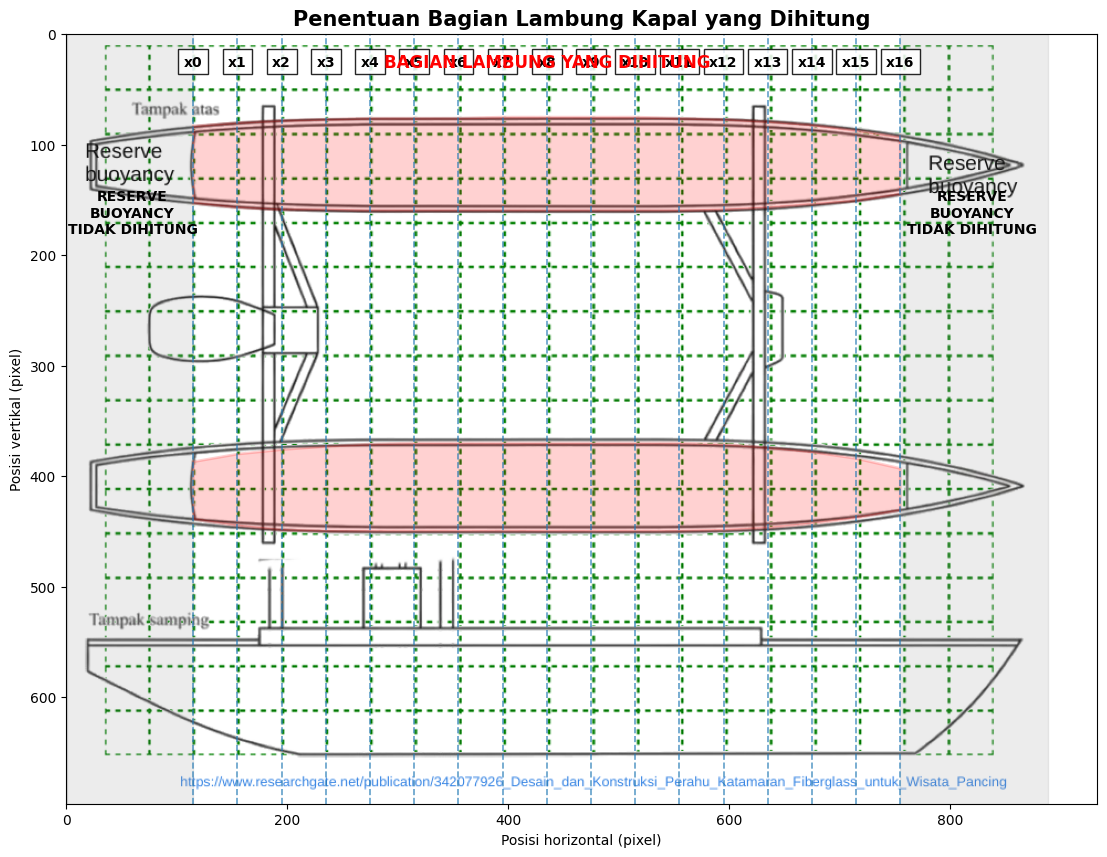

In [122]:
from matplotlib.patches import Polygon, Rectangle

plt.figure(figsize=(16, 10))
ax = plt.gca()

# Menampilkan gambar kapal asli
ax.imshow(gambar)

# TITIK PENGUKURAN
x_titik = [115 + i * 40 for i in range(17)]

for i, x_pos in enumerate(x_titik):
    ax.axvline(
        x=x_pos,
        linestyle="--",
        linewidth=1.2,
        alpha=0.7
    )

    ax.text(
        x_pos,
        25,
        f"x{i}",
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            alpha=0.85,
            edgecolor="black"
        )
    )

# ARSIR LAMBUNG ATAS
lambung_atas = [
    (115, 83),
    (155, 80),
    (195, 78),
    (235, 77),
    (275, 76),
    (315, 76),
    (355, 76),
    (395, 75),
    (435, 75),
    (475, 75),
    (515, 75),
    (555, 76),
    (595, 77),
    (635, 79),
    (675, 82),
    (715, 87),
    (755, 93),
    (755, 145),
    (715, 151),
    (675, 154),
    (635, 157),
    (595, 159),
    (555, 160),
    (515, 160),
    (475, 160),
    (435, 160),
    (395, 160),
    (355, 160),
    (315, 160),
    (275, 160),
    (235, 159),
    (195, 159),
    (155, 157),
    (115, 153)
]

ax.add_patch(
    Polygon(
        lambung_atas,
        closed=True,
        facecolor="red",
        alpha=0.18,
        edgecolor="red",
        linewidth=2
    )
)

# ARSIR LAMBUNG BAWAH
lambung_bawah = [
    (115, 387),
    (155, 380),
    (195, 376),
    (235, 373),
    (275, 371),
    (315, 370),
    (355, 370),
    (395, 370),
    (435, 370),
    (475, 370),
    (515, 370),
    (555, 370),
    (595, 371),
    (635, 374),
    (675, 378),
    (715, 384),
    (755, 393),
    (755, 431),
    (715, 438),
    (675, 443),
    (635, 447),
    (595, 449),
    (555, 450),
    (515, 450),
    (475, 450),
    (435, 450),
    (395, 450),
    (355, 450),
    (315, 450),
    (275, 450),
    (235, 450),
    (195, 449),
    (155, 445),
    (115, 439)
]

ax.add_patch(
    Polygon(
        lambung_bawah,
        closed=True,
        facecolor="red",
        alpha=0.18,
        edgecolor="red",
        linewidth=2
    )
)

# RESERVE BUOYANCY
ax.axvspan(0, 115, color="gray", alpha=0.15)
ax.axvspan(755, 889, color="gray", alpha=0.15)

ax.text(
    60, 180,
    "RESERVE\nBUOYANCY\nTIDAK DIHITUNG",
    ha="center",
    fontsize=10,
    fontweight="bold"
)

ax.text(
    820, 180,
    "RESERVE\nBUOYANCY\nTIDAK DIHITUNG",
    ha="center",
    fontsize=10,
    fontweight="bold"
)

ax.text(
    435, 30,
    "BAGIAN LAMBUNG YANG DIHITUNG",
    ha="center",
    fontsize=12,
    fontweight="bold",
    color="red"
)

ax.set_title(
    "Penentuan Bagian Lambung Kapal yang Dihitung",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Posisi horizontal (pixel)")
ax.set_ylabel("Posisi vertikal (pixel)")

plt.show()

Berdasarkan pembagian grid, daerah utama lambung yang dihitung memiliki panjang 1,6 m. Daerah tersebut dibagi menjadi 16 interval yang sama panjang, dengan jarak antar penampang sebesar 0,1 m. Dengan demikian diperoleh 17 titik pengukuran yang digunakan sebagai dasar perhitungan volume secara numerik

## **3. Menentukan Ukuran Penampang pada Setiap Titik dan Menghitung luasnya**

Berdasarkan titik pengukuran yang telah ditentukan sebelumnya, terdapat **17 titik** dengan jarak antar titik sebesar **10 cm**. Posisi pengukuran dimulai dari **0 cm sampai 160 cm**.

Pada setiap titik pengukuran, ditentukan dua ukuran, yaitu **lebar lambung** dari tampak atas dan **tinggi lambung** dari tampak samping. Nilai lebar dan tinggi diperoleh melalui pembacaan pendekatan berdasarkan grid pada gambar.

Lebar lambung pada setiap titik tidak selalu sama. Bagian tengah lambung memiliki lebar yang relatif lebih besar, sedangkan bagian menuju ujung kapal semakin mengecil. Hal ini menunjukkan bahwa bentuk lambung tidak sepenuhnya berbentuk balok.

Sesuai dengan ketentuan soal, lantai kapal dianggap datar. Oleh karena itu, tinggi bagian utama lambung digunakan sebesar **25,50 cm** pada setiap titik pengukuran.

Selanjutnya, ukuran yang masih dalam satuan sentimeter dikonversikan ke meter agar satuan yang digunakan dalam perhitungan volume menjadi konsisten.

Konversi yang digunakan adalah:

**1 cm = 0,01 m**

Setelah lebar dan tinggi dikonversikan ke meter, luas penampang pada setiap titik dihitung dengan rumus:

$$
A(x) = lebar \times tinggi
$$

Hasil perhitungan tersebut disimpan dalam tabel `data`. Tabel tersebut berisi nomor titik pengukuran, posisi titik pada arah memanjang kapal, lebar lambung, tinggi lambung, dan luas penampang pada setiap titik.



In [123]:
# Jarak titik pengukuran
x_cm = np.arange(0, 161, 10)

# Lebar lambung dari tampak atas
lebar_cm = np.array([
    18.00, 19.50, 21.00, 21.25, 21.50, 21.50,
    21.50, 21.50, 21.50, 21.50, 21.50, 21.50,
    21.00, 20.50, 19.00, 16.75, 13.75
])

# Tinggi lambung
tinggi_cm = np.full(17, 25.50)

# Luas penampang
luas_cm2 = lebar_cm * tinggi_cm

# Konversi ke meter
x = x_cm / 100
lebar = lebar_cm / 100
tinggi = tinggi_cm / 100
luas = luas_cm2 / 10000

# Tabel
data = pd.DataFrame({
    "Titik": [f"x{i}" for i in range(17)],
    "x (m)": x,
    "Lebar (m)": lebar,
    "Tinggi (m)": tinggi,
    "Luas Penampang (m²)": luas
})

data

,Titik,x (m),Lebar (m),Tinggi (m),Luas Penampang (m²)
0,x0,0.0,0.1800,0.255,0.045900
1,x1,0.1,0.1950,0.255,0.049725
2,x2,0.2,0.2100,0.255,0.053550
3,x3,0.3,0.2125,0.255,0.054187
4,x4,0.4,0.2150,0.255,0.054825
5,x5,0.5,0.2150,0.255,0.054825
6,x6,0.6,0.2150,0.255,0.054825
7,x7,0.7,0.2150,0.255,0.054825
8,x8,0.8,0.2150,0.255,0.054825
9,x9,0.9,0.2150,0.255,0.054825


Berdasarkan hasil perhitungan, luas penampang berbeda pada setiap posisi sepanjang bagian utama lambung. Luas penampang cenderung lebih kecil pada bagian ujung dan lebih besar pada bagian tengah. Hal ini sesuai dengan bentuk lambung pada gambar yang semakin lebar pada bagian tengah dan mengecil menuju ujung.

Nilai luas penampang pada setiap titik selanjutnya digunakan sebagai fungsi diskrit A(x) dalam perhitungan volume menggunakan metode integrasi numerik.

## **4. Menghitung Volume Satu Lambung dengan Metode Simpson 1/3**

Setelah luas penampang pada setiap titik diperoleh, langkah berikutnya adalah menghitung volume satu lambung kapal. Volume diperoleh dengan mengintegralkan luas penampang terhadap panjang kapal.

Jarak antar titik pengukuran adalah:

$$
h = 0,1\text{ m}
$$

Secara matematis, volume dapat dinyatakan sebagai:

$$
V = \int A(x)\,dx
$$

Karena luas penampang hanya diketahui pada titik-titik pengukuran, maka integral dihitung secara numerik menggunakan metode Simpson 1/3.

Terdapat 16 interval dengan jarak yang sama, sehingga metode Simpson 1/3 dapat digunakan untuk menghitung volume satu lambung kapal.

In [124]:
# Jarak antar titik
h = 0.1  # meter

# Komponen Simpson
A_ganjil = np.sum(luas[1:-1:2])
A_genap = np.sum(luas[2:-1:2])

print(f"A0              = {luas[0]:.6f} m²")
print(f"A16             = {luas[-1]:.6f} m²")
print(f"Jumlah A ganjil = {A_ganjil:.6f} m²")
print(f"Jumlah A genap  = {A_genap:.6f} m²")

print()
print(f"4 × jumlah A ganjil = {4*A_ganjil:.6f}")
print(f"2 × jumlah A genap  = {2*A_genap:.6f}")

print()
print(f"Volume = ({h}/3) × "
      f"({luas[0]:.6f} + {luas[-1]:.6f} "
      f"+ 4({A_ganjil:.6f}) "
      f"+ 2({A_genap:.6f}))")

# Metode Simpson 1/3
V_satu_lambung = (h / 3) * (
    luas[0] + luas[-1]
    + 4 * A_ganjil
    + 2 * A_genap
)

print(f"Volume satu lambung = {V_satu_lambung:.6f} m³")
print(f"Volume satu lambung = {V_satu_lambung * 1000:.2f} liter")


A0              = 0.045900 m²
A16             = 0.035063 m²
Jumlah A ganjil = 0.418200 m²
Jumlah A genap  = 0.374850 m²

4 × jumlah A ganjil = 1.672800
2 × jumlah A genap  = 0.749700

Volume = (0.1/3) × (0.045900 + 0.035063 + 4(0.418200) + 2(0.374850))
Volume satu lambung = 0.083449 m³
Volume satu lambung = 83.45 liter


Berdasarkan metode Simpson 1/3, diperoleh volume **satu lambung kapal sebesar 0,083449 m³ atau sekitar 83,45 liter**. Nilai tersebut diperoleh dari 17 titik pengukuran dengan jarak antar titik sebesar 0,1 m. Perhitungan hanya mencakup bagian utama lambung kapal, sedangkan bagian **reserve buoyancy** pada kedua ujung kapal tidak dimasukkan.

## **5. Menghitung Volume Kedua Lambung dengan Metode Simpson 1/3**

Kapal yang dianalisis memiliki dua lambung. Dengan asumsi kedua lambung memiliki bentuk dan ukuran yang sama, volume total kedua lambung diperoleh dengan mengalikan volume satu lambung dengan dua.

Rumus yang digunakan:

$$
V_{\text{total}} = 2V_{\text{satu lambung}}
$$

Berdasarkan hasil metode Simpson 1/3:

$$
V_{\text{total}} = 2(0,083449)
$$

Sehingga diperoleh:

$$
V_{\text{total}} = 0,166898\text{ m}^3
$$

atau sekitar **166,90 liter**.

In [127]:
# Jumlah lambung
jumlah_lambung = 2

# Volume total kedua lambung
V_total = jumlah_lambung * V_satu_lambung

print(f"Volume satu lambung  = {V_satu_lambung:.6f} m³")
print(f"Volume kedua lambung = {V_total:.6f} m³")

print(f"\nVolume satu lambung  = {V_satu_lambung * 1000:.2f} liter")
print(f"Volume kedua lambung = {V_total * 1000:.2f} liter")

Volume satu lambung  = 0.083449 m³
Volume kedua lambung = 0.166898 m³

Volume satu lambung  = 83.45 liter
Volume kedua lambung = 166.90 liter


## **6. Menghitung Volume Lambung dengan Metode Trapesium**

Selain metode Simpson 1/3, volume lambung kapal juga dihitung menggunakan metode Trapesium sebagai pembanding.

Metode Trapesium digunakan untuk mendekati nilai integral berdasarkan luas penampang pada setiap titik pengukuran. Rumus yang digunakan adalah:

$$
V \approx h\left[
\frac{A_0 + A_n}{2}
+ A_1 + A_2 + \cdots + A_{n-1}
\right]
$$

$$
V_T = h\left[
\frac{A_0 + A_{16}}{2}
+ A_1 + A_2 + \cdots + A_{15}
\right]
$$

dengan:

- \(V\) = volume lambung
- \(h\) = jarak antar titik, yaitu 0,1 m
- \(A_n\) = luas penampang pada titik ke-\(n\)

Perhitungan dilakukan menggunakan 17 titik pengukuran atau 16 interval dengan jarak yang sama.

In [129]:
# Menghitung volume satu lambung
V_trapesium = np.trapezoid(luas, x)

# Karena terdapat dua lambung yang dianggap sama
V_total_trapesium = 2 * V_trapesium

print(f"Volume satu lambung  = {V_trapesium:.6f} m³")
print(f"Volume kedua lambung = {V_total_trapesium:.6f} m³")

print()
print(f"Volume satu lambung  = {V_trapesium * 1000:.2f} liter")
print(f"Volume kedua lambung = {V_total_trapesium * 1000:.2f} liter")

Volume satu lambung  = 0.083353 m³
Volume kedua lambung = 0.166706 m³

Volume satu lambung  = 83.35 liter
Volume kedua lambung = 166.71 liter


Berdasarkan metode Trapesium, diperoleh volume satu lambung sebesar **0,083353 m³ atau sekitar 83,35 liter**. Dengan dua lambung yang dianggap memiliki ukuran sama, volume total kedua lambung adalah **0,166706 m³ atau sekitar 166,71 liter**.

## **7. Membandingkan Hasil Metode Simpson 1/3 dan Trapesium**

Setelah volume dihitung menggunakan metode Simpson 1/3 dan Trapesium, kedua hasil tersebut dibandingkan untuk mengetahui selisih volume yang diperoleh dari masing-masing metode.

In [130]:
# Selisih volume satu lambung
selisih = abs(V_satu_lambung - V_trapesium)

# Persentase selisih terhadap hasil Simpson
persen_selisih = (selisih / V_satu_lambung) * 100

# Volume kedua lambung
V_total_simpson = 2 * V_satu_lambung
V_total_trapesium = 2 * V_trapesium

# Selisih volume kedua lambung
selisih_total = abs(V_total_simpson - V_total_trapesium)

print(f"Volume Simpson 1/3 = {V_satu_lambung:.9f} m³")
print(f"Volume Trapesium   = {V_trapesium:.9f} m³")
print(f"Selisih            = {selisih:.9f} m³")
print(f"Selisih            = {selisih * 1000:.3f} liter")
print(f"Persentase selisih = {persen_selisih:.3f}%")

print("\nUntuk kedua lambung:")
print(f"Volume Simpson     = {V_total_simpson:.9f} m³")
print(f"Volume Trapesium   = {V_total_trapesium:.9f} m³")
print(f"Selisih volume     = {selisih_total:.9f} m³")
print(f"Selisih volume     = {selisih_total * 1000:.3f} liter")

Volume Simpson 1/3 = 0.083448750 m³
Volume Trapesium   = 0.083353125 m³
Selisih            = 0.000095625 m³
Selisih            = 0.096 liter
Persentase selisih = 0.115%

Untuk kedua lambung:
Volume Simpson     = 0.166897500 m³
Volume Trapesium   = 0.166706250 m³
Selisih volume     = 0.000191250 m³
Selisih volume     = 0.191 liter


Hasil kedua metode memiliki selisih yang kecil. Untuk dua lambung, selisih volume yang diperoleh adalah **0,000191 m³ atau sekitar 0,191 liter**, dengan persentase selisih sebesar **0,115%**. Hal ini menunjukkan bahwa hasil metode Simpson 1/3 dan Trapesium relatif berdekatan.

**a). Tabel perbandingan dari 2 metode**

In [132]:
# Tabel perbandingan metode
perbandingan = pd.DataFrame({
    "Metode": ["Simpson 1/3", "Trapesium"],

    "Volume 1 Lambung (m³)": [
        V_satu_lambung,
        V_trapesium
    ],

    "Volume 2 Lambung (m³)": [
        V_total_simpson,
        V_total_trapesium
    ],

    "Volume 1 Lambung (liter)": [
        V_satu_lambung * 1000,
        V_trapesium * 1000
    ],

    "Volume 2 Lambung (liter)": [
        V_total_simpson * 1000,
        V_total_trapesium * 1000
    ]
})

perbandingan

,Metode,Volume 1 Lambung (m³),Volume 2 Lambung (m³),Volume 1 Lambung (liter),Volume 2 Lambung (liter)
0,Simpson 1/3,0.083449,0.166898,83.448750,166.89750
1,Trapesium,0.083353,0.166706,83.353125,166.70625


**Kesimpulan**

Berdasarkan perhitungan volume kedua lambung kapal menggunakan metode integrasi numerik, diperoleh volume sebesar 0,166898 m³ atau sekitar 166,90 liter dengan metode Simpson 1/3. Sementara itu, metode Trapesium menghasilkan volume sebesar 0,166706 m³ atau sekitar 166,71 liter.

Selisih kedua metode tersebut adalah sekitar 0,000191 m³ atau 0,191 liter, dengan persentase selisih sekitar 0,115%. Hasil yang relatif berdekatan menunjukkan bahwa kedua metode memberikan hasil perhitungan volume yang hampir sama pada data yang digunakan.

Dengan demikian, volume kedua lambung kapal yang diperoleh dalam perhitungan ini adalah sekitar 0,167 m³ atau 166,90 liter berdasarkan metode Simpson 1/3.